# Model Evaluation Notebook — Agent Fact Detection System

This notebook performs **individual evaluation** of each pre-trained model used in the pipeline:

| # | Model | Task | Metric |
|---|-------|------|--------|
| 1 | `openai/whisper-large_v3` | Speech-to-Text (ASR) | WER (Word Error Rate) |
| 2 | `cross-encoder/nli-deberta-v3-large_v3` | Natural Language Inference | Accuracy, F1, Confusion Matrix |

> **Note:** The Brave Search API is a data retrieval tool, not a trainable model — no evaluation needed there.

---


---
## 1. Whisper ASR Evaluation

We evaluate the `openai/whisper-large_v3` model using two datasets:

- **Mozilla Common Voice 11 (Spanish)** — Real-world multilingual speech, relevant to our use case.
- **LibriSpeech ASR (English, test-clean)** — The standard benchmark for clean read speech.

**Metric: WER (Word Error Rate)**

$$WER = \frac{S + D + I}{N}$$

Where `S`=substitutions, `D`=deletions, `I`=insertions, `N`=total words in reference.  
Lower is better (0% = perfect).


In [1]:
import os

# 1. Define tu ruta absoluta aquí
mi_ruta = "/home/alumno/Desktop/datos/TFM/Dem_Biases_Gen_Img_Models/models"

# 2. Inyecta las variables en el sistema ANTES de importar Hugging Face
os.environ["HF_HOME"] = mi_ruta
os.environ["HF_DATASETS_CACHE"] = mi_ruta

# 3. AHORA importamos las librerías
from datasets import load_dataset,Audio
import datasets

# 4. Sobrescribimos la configuración interna de la librería por si acaso
datasets.config.HF_DATASETS_CACHE = mi_ruta
datasets.config.DOWNLOADED_DATASETS_PATH = mi_ruta

print(f"Caché forzada a: {datasets.config.HF_DATASETS_CACHE}")

Caché forzada a: /home/alumno/Desktop/datos/TFM/Dem_Biases_Gen_Img_Models/models


In [2]:
import warnings
warnings.filterwarnings("ignore")

import torch
import whisper
import jiwer
import numpy as np
import pandas as pd
from tqdm import tqdm

# Setup
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_SAMPLES = 50  # Number of samples to evaluate (increase for more rigour)

print(f"Using device: {DEVICE.upper()}")
print(f"Loading Whisper 'large-v3' model...")

model = whisper.load_model("large-v3", device=DEVICE)
print("Whisper model loaded.")


Using device: CUDA
Loading Whisper 'large-v3' model...
Whisper model loaded.


### 1.1 Evaluation on PolyAI Minds14

In [3]:
# 2. Load the mini dataset (natively 8kHz)
ds_mini = load_dataset(
    "PolyAI/minds14",
    "es-ES",
    split="train",
    cache_dir=mi_ruta
)
# 3. The 1-Line Magic: Resample to 16kHz automatically
ds_mini = ds_mini.cast_column("audio", Audio(sampling_rate=16000))

# 4. Verify the new sampling rate
sample = ds_mini[0]["audio"]
print(f"Transcription: {ds_mini[0]['transcription']}")
print(f"New Sampling Rate: {sample['sampling_rate']} Hz")

Transcription: hola buenas a ver tengo un problema con vuestra aplicación resulta que quiero hacer una transferencia bancaria a una cuenta conocida
New Sampling Rate: 16000 Hz


In [4]:
import librosa
import numpy as np
import whisper

def transcribe_audio_array(model, audio_array, sampling_rate=16000):
    """Transcribe a numpy audio array with Whisper."""
    
    # Whisper expects float32 mono at 16kHz
    audio = audio_array.astype(np.float32)
    
    # Resample defensively if needed
    if sampling_rate != 16000:
        audio = librosa.resample(audio, orig_sr=sampling_rate, target_sr=16000)
        
    # Pad or trim to 30s window
    audio = whisper.pad_or_trim(audio)
    
    # FIX: Dynamically set the number of Mel channels based on the model (128 for large-v3)
    mel = whisper.log_mel_spectrogram(audio, n_mels=model.dims.n_mels).to(model.device)
    
    # Define options: explicitly set language to Spanish to prevent hallucinations
    options = whisper.DecodingOptions(
        language="es", 
        fp16=(model.device.type == "cuda") # Dynamically check the model's device
    )
    
    # Decode the audio
    result = whisper.decode(model, mel, options)
    
    return result.text

# 1. Define the transformation pipeline
transformation = jiwer.Compose([
    jiwer.ToLowerCase(),
    jiwer.RemovePunctuation(),
    jiwer.Strip(),
    jiwer.RemoveMultipleSpaces(),
])

In [5]:
references = []
hypotheses = []

print("Running inference on Minds14 (es)...")

for sample in tqdm(ds_mini, desc="Evaluating"):
    # Fixed the column name for the ground-truth text
    ref =sample["transcription"]
    audio_array = np.array(sample["audio"]["array"])
    sr = sample["audio"]["sampling_rate"]

    try:
        hyp = transcribe_audio_array(model, audio_array, sampling_rate=sr)
        references.append(ref)
        hypotheses.append(hyp)
    except Exception as e:
        print(f"Skipped sample: {e}")

base_cleaning = [
    jiwer.ToLowerCase(),
    jiwer.RemovePunctuation(),
    jiwer.Strip(),
    jiwer.RemoveMultipleSpaces(),
]
# 2. Add the specific splitting behavior for WER and CER
wer_transform = jiwer.Compose(base_cleaning + [jiwer.ReduceToListOfListOfWords()])
cer_transform = jiwer.Compose(base_cleaning + [jiwer.ReduceToListOfListOfChars()])

# 3. Calculate the scores using their respective transforms
wer_score_mind = jiwer.wer(
    references, 
    hypotheses, 
    reference_transform=wer_transform, 
    hypothesis_transform=wer_transform
)

cer_score_mind = jiwer.cer(
    references, 
    hypotheses, 
    reference_transform=cer_transform, 
    hypothesis_transform=cer_transform
)

print(f"\nEvaluation Results:")
print(f"  WER : {wer_score_mind * 100:.2f}%")
print(f"  CER : {cer_score_mind * 100:.2f}%")

Running inference on Minds14 (es)...


Evaluating: 100%|█████████████████████████████| 486/486 [10:53<00:00,  1.35s/it]


Evaluation Results:
  WER : 27.56%
  CER : 21.66%


### 1.2 Evaluation on LibriSpeech (English, test-clean)

In [6]:
print("Conectando con Multilingual LibriSpeech (Español) en streaming...")

# Usamos el repositorio correcto para la versión multilingüe
ds_ls = load_dataset(
    "facebook/multilingual_librispeech",
    "spanish",
    split="test",
    trust_remote_code=True
)
print(f"Loaded {len(ds_ls)} samples from LibriSpeech test-clean.")


Conectando con Multilingual LibriSpeech (Español) en streaming...


Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Loaded 2385 samples from LibriSpeech test-clean.


In [8]:
references_ls = []
hypotheses_ls = []

print("Running inference on Multilingual LibriSpeech...")

for sample in tqdm(ds_ls, desc="LibriSpeech ES"):
    # Fixed: The correct column name for this dataset is 'transcript'
    ref = sample["transcript"] 
    audio_array = np.array(sample["audio"]["array"])
    sr = sample["audio"]["sampling_rate"]

    try:
        hyp = transcribe_audio_array(model, audio_array, sampling_rate=sr)
        references_ls.append(ref)
        hypotheses_ls.append(hyp)
    except Exception as e:
        print(f"Skipped sample: {e}")

base_cleaning = [
    jiwer.ToLowerCase(),
    jiwer.RemovePunctuation(),
    jiwer.Strip(),
    jiwer.RemoveMultipleSpaces(),
]
wer_transform = jiwer.Compose(base_cleaning + [jiwer.ReduceToListOfListOfWords()])
cer_transform = jiwer.Compose(base_cleaning + [jiwer.ReduceToListOfListOfChars()])

# 6. Calcular métricas finales
wer_score_lispeech = jiwer.wer(
    references_ls, 
    hypotheses_ls, 
    reference_transform=wer_transform, 
    hypothesis_transform=wer_transform
)
cer_score_lispeech = jiwer.cer(
    references_ls, 
    hypotheses_ls, 
    reference_transform=cer_transform, 
    hypothesis_transform=cer_transform
)

print(f"\nResultados LibriSpeech (test-clean):")
print(f"  WER : {wer_score_lispeech * 100:.2f}%")
print(f"  CER : {cer_score_lispeech * 100:.2f}%")

Running inference on Multilingual LibriSpeech...


LibriSpeech ES: 100%|█████████████████████| 2385/2385 [1:20:41<00:00,  2.03s/it]



Resultados LibriSpeech (test-clean):
  WER : 4.00%
  CER : 1.40%


### 1.3 Whisper Results Summary & Visualisation

  WHISPER large_v3 — EVALUATION SUMMARY


,Dataset,Samples,WER (%),CER (%)
0,Multilingual LibriSpeech,2385,4.00,1.40
1,Minds14 (ES),486,27.56,21.66


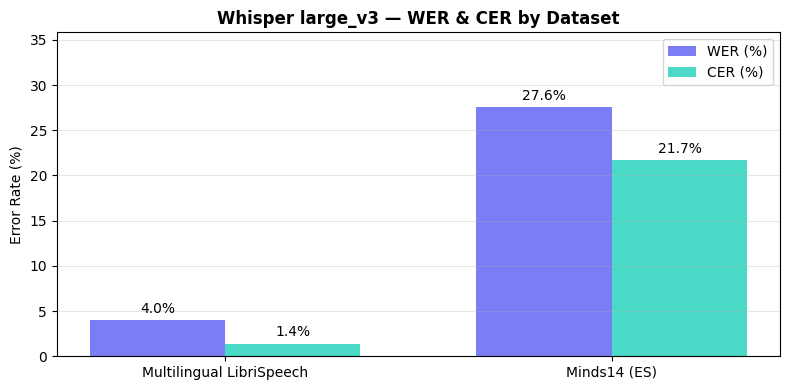

Chart saved as whisper_evaluation.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Summary Table ────────────────────────────────────────────────────────────
results_whisper = pd.DataFrame({
    # Updated the names of the datasets
    "Dataset": ["Multilingual LibriSpeech", "Minds14 (ES)"],
    # Changed references_cv to references (which is what you used for Minds14)
    "Samples": [len(references_ls), len(references)],
    "WER (%)": [round(wer_score_lispeech * 100, 2), round(wer_score_mind * 100, 2)],
    "CER (%)": [round(cer_score_lispeech * 100, 2), round(cer_score_mind * 100, 2)],
})
print("=" * 50)
print("  WHISPER large_v3 — EVALUATION SUMMARY")
print("=" * 50)
display(results_whisper)

# ── Bar Chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(results_whisper))
width = 0.35

bars1 = ax.bar(x - width/2, results_whisper["WER (%)"], width, label="WER (%)", color="#6366f1", alpha=0.85)
bars2 = ax.bar(x + width/2, results_whisper["CER (%)"], width, label="CER (%)", color="#2dd4bf", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(results_whisper["Dataset"])
ax.set_ylabel("Error Rate (%)")
ax.set_title("Whisper large_v3 — WER & CER by Dataset", fontweight="bold")
ax.legend()
ax.bar_label(bars1, padding=3, fmt="%.1f%%")
ax.bar_label(bars2, padding=3, fmt="%.1f%%")
ax.set_ylim(0, max(results_whisper["WER (%)"].max(), results_whisper["CER (%)"].max()) * 1.3)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.savefig("whisper_evaluation.png", dpi=150)
plt.show()
print("Chart saved as whisper_evaluation.png")



---
## 2. NLI Cross-Encoder Evaluation

We evaluate `cross-encoder/nli-deberta-v3-base` on:

- **MultiNLI** (`multi_nli`, `validation_matched`) — Gold standard English NLI benchmark.
- **XNLI** (`xnli`, language `es`) — Multilingual NLI, key for our Spanish news use case.

**Metrics:** Accuracy, F1-Score (macro), Confusion Matrix.

**Label Mapping:**

| MultiNLI label | Our Label |
|---|---|
| 0 — entailment | entailment |
| 1 — neutral | neutral |
| 2 — contradiction | contradiction |


In [12]:
from sentence_transformers import CrossEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

NLI_N_SAMPLES = 200  # Number of samples per dataset

print(f"NLI model device: {DEVICE.upper()}")
print("Loading NLI Cross-Encoder...")
nli_model = CrossEncoder("cross-encoder/nli-deberta-v3-base", device=DEVICE)
print("NLI model loaded.")


NLI model device: CUDA
Loading NLI Cross-Encoder...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: cross-encoder/nli-deberta-v3-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NLI model loaded.


### 2.1 Evaluation on MultiNLI (English, validation matched)

In [13]:
print("Loading MultiNLI validation_matched...")

ds_mnli = load_dataset("multi_nli", split=f"validation_matched[:{NLI_N_SAMPLES}]")
print(f"Loaded {len(ds_mnli)} samples from MultiNLI.")

# MultiNLI labels: 0=entailment, 1=neutral, 2=contradiction
LABEL_MAP_MNLI = {0: "entailment", 1: "neutral", 2: "contradiction"}
# cross-encoder/nli-deberta-v3-base output order: contradiction(0), entailment(1), neutral(2)
CE_IDX_TO_LABEL = {0: "contradiction", 1: "entailment", 2: "neutral"}

pairs_mnli = [(row["premise"], row["hypothesis"]) for row in ds_mnli]
true_labels_mnli = [LABEL_MAP_MNLI[row["label"]] for row in ds_mnli]

print("Running NLI inference on MultiNLI...")
scores_mnli = nli_model.predict(pairs_mnli, show_progress_bar=True)
pred_labels_mnli = [CE_IDX_TO_LABEL[s.argmax()] for s in scores_mnli]

acc_mnli = accuracy_score(true_labels_mnli, pred_labels_mnli)
f1_mnli  = f1_score(true_labels_mnli, pred_labels_mnli, average="macro")

print(f"\nMultiNLI (EN) Results:")
print(f"Accuracy : {acc_mnli * 100:.2f}%")
print(f"F1 Macro : {f1_mnli * 100:.2f}%")
print("\n" + classification_report(true_labels_mnli, pred_labels_mnli))


Loading MultiNLI validation_matched...
Loaded 200 samples from MultiNLI.
Running NLI inference on MultiNLI...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


MultiNLI (EN) Results:
Accuracy : 88.00%
F1 Macro : 87.96%

               precision    recall  f1-score   support

contradiction       0.92      0.93      0.92        59
   entailment       0.93      0.85      0.89        82
      neutral       0.78      0.86      0.82        59

     accuracy                           0.88       200
    macro avg       0.88      0.88      0.88       200
 weighted avg       0.88      0.88      0.88       200



### 2.2 Evaluation on XNLI (Spanish)

In [14]:
print("Loading XNLI (es)...")

ds_xnli = load_dataset("xnli", "es", split=f"test[:{NLI_N_SAMPLES}]")
print(f"Loaded {len(ds_xnli)} samples from XNLI (es).")

# XNLI labels: 0=entailment, 1=neutral, 2=contradiction
LABEL_MAP_XNLI = {0: "entailment", 1: "neutral", 2: "contradiction"}

pairs_xnli = [(row["premise"], row["hypothesis"]) for row in ds_xnli]
true_labels_xnli = [LABEL_MAP_XNLI[row["label"]] for row in ds_xnli]

print("Running NLI inference on XNLI (es)...")
scores_xnli = nli_model.predict(pairs_xnli, show_progress_bar=True)
pred_labels_xnli = [CE_IDX_TO_LABEL[s.argmax()] for s in scores_xnli]

acc_xnli = accuracy_score(true_labels_xnli, pred_labels_xnli)
f1_xnli  = f1_score(true_labels_xnli, pred_labels_xnli, average="macro")

print(f"\XNLI (ES) Results:")
print(f"  Accuracy : {acc_xnli * 100:.2f}%")
print(f"  F1 Macro : {f1_xnli * 100:.2f}%")
print("\n" + classification_report(true_labels_xnli, pred_labels_xnli))


Loading XNLI (es)...
Loaded 200 samples from XNLI (es).
Running NLI inference on XNLI (es)...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

\XNLI (ES) Results:
  Accuracy : 79.50%
  F1 Macro : 79.08%

               precision    recall  f1-score   support

contradiction       0.86      0.91      0.88        67
   entailment       0.95      0.58      0.72        67
      neutral       0.67      0.89      0.77        66

     accuracy                           0.80       200
    macro avg       0.83      0.80      0.79       200
 weighted avg       0.83      0.80      0.79       200



### 2.3 NLI Results Summary & Confusion Matrices

  NLI CROSS-ENCODER DeBERTa-v3-base — EVALUATION SUMMARY


,Dataset,Samples,Accuracy (%),F1 Macro (%)
0,MultiNLI (EN matched),200,88.0,87.96
1,XNLI (ES),200,79.5,79.08


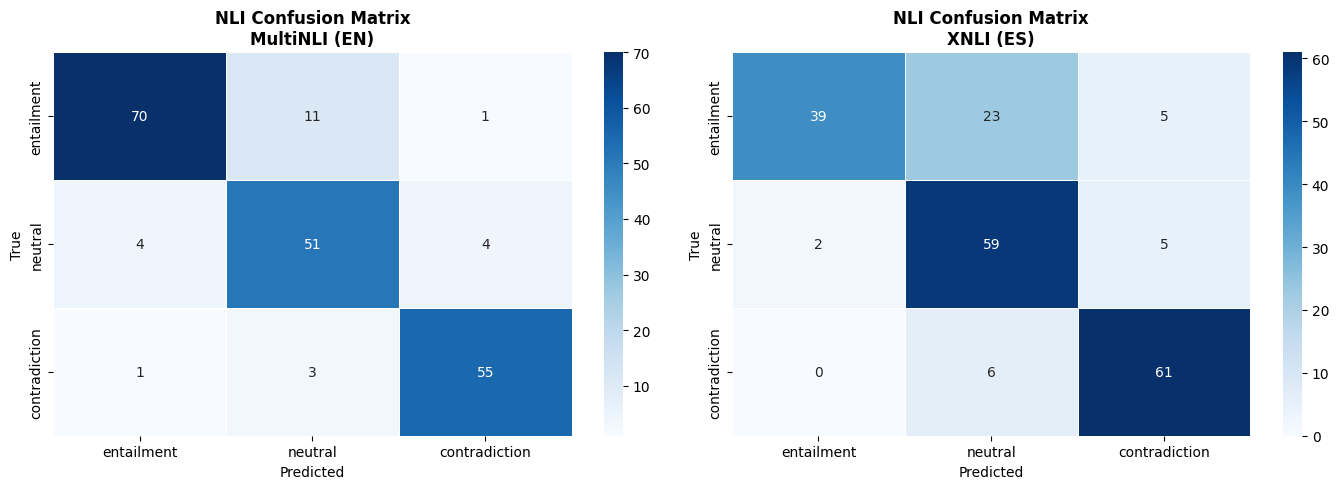

Chart saved as nli_confusion_matrices.png


In [15]:
# ── Summary Table ────────────────────────────────────────────────────────────
results_nli = pd.DataFrame({
    "Dataset": ["MultiNLI (EN matched)", "XNLI (ES)"],
    "Samples": [NLI_N_SAMPLES, NLI_N_SAMPLES],
    "Accuracy (%)": [round(acc_mnli * 100, 2), round(acc_xnli * 100, 2)],
    "F1 Macro (%)": [round(f1_mnli * 100, 2), round(f1_xnli * 100, 2)],
})

print("=" * 60)
print("  NLI CROSS-ENCODER DeBERTa-v3-base — EVALUATION SUMMARY")
print("=" * 60)
display(results_nli)

# ── Confusion Matrices ────────────────────────────────────────────────────────
LABELS = ["entailment", "neutral", "contradiction"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, true_l, pred_l, title in [
    (axes[0], true_labels_mnli, pred_labels_mnli, "MultiNLI (EN)"),
    (axes[1], true_labels_xnli, pred_labels_xnli, "XNLI (ES)"),
]:
    cm = confusion_matrix(true_l, pred_l, labels=LABELS)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=LABELS, yticklabels=LABELS,
        ax=ax, linewidths=0.5
    )
    ax.set_title(f"NLI Confusion Matrix\n{title}", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

fig.tight_layout()
plt.savefig("nli_confusion_matrices.png", dpi=150)
plt.show()
print("Chart saved as nli_confusion_matrices.png")


---
## 3. Global Summary

  AGENT FACT DETECTION SYSTEM — FULL EVALUATION SUMMARY

WHISPER large_v3 (ASR):


,Dataset,Samples,WER (%),CER (%)
0,Multilingual LibriSpeech,2385,4.00,1.40
1,Minds14 (ES),486,27.56,21.66



NLI CROSS-ENCODER DeBERTa-v3-base:


,Dataset,Samples,Accuracy (%),F1 Macro (%)
0,MultiNLI (EN matched),200,88.0,87.96
1,XNLI (ES),200,79.5,79.08


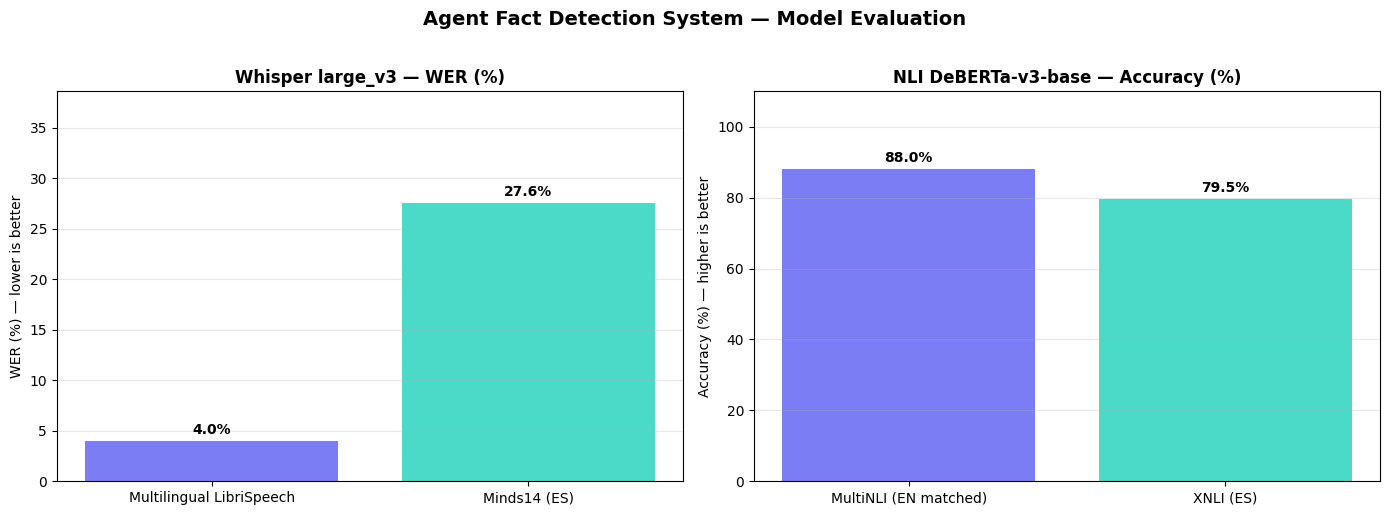


 All evaluations completed! Charts saved.


In [16]:
print("=" * 65)
print("  AGENT FACT DETECTION SYSTEM — FULL EVALUATION SUMMARY")
print("=" * 65)

print("\nWHISPER large_v3 (ASR):")
display(results_whisper)

print("\nNLI CROSS-ENCODER DeBERTa-v3-base:")
display(results_nli)

# ── Combined visual summary ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Whisper WER bars
ax = axes[0]
colors = ["#6366f1", "#2dd4bf"]
bars = ax.bar(results_whisper["Dataset"], results_whisper["WER (%)"], color=colors, alpha=0.85)
ax.bar_label(bars, padding=3, fmt="%.1f%%", fontweight="bold")
ax.set_title("Whisper large_v3 — WER (%)", fontweight="bold")
ax.set_ylabel("WER (%) — lower is better")
ax.set_ylim(0, max(results_whisper["WER (%)"]) * 1.4)
ax.grid(axis="y", alpha=0.3)

# NLI Accuracy bars
ax = axes[1]
bars = ax.bar(results_nli["Dataset"], results_nli["Accuracy (%)"], color=colors, alpha=0.85)
ax.bar_label(bars, padding=3, fmt="%.1f%%", fontweight="bold")
ax.set_title("NLI DeBERTa-v3-base — Accuracy (%)", fontweight="bold")
ax.set_ylabel("Accuracy (%) — higher is better")
ax.set_ylim(0, 110)
ax.grid(axis="y", alpha=0.3)

fig.suptitle("Agent Fact Detection System — Model Evaluation", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.savefig("full_evaluation_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n All evaluations completed! Charts saved.")
